# Heat-Death Forecast + Google-Style Map + LVMPD Homicide Comparison

This notebook is a clean rebuild of the previous version.

The goal is **not** to use the missing `combined_all.csv` or the old assault/ADF pipeline. Instead, this notebook does four things:

1. Builds a clean heat-related death time series from the available coroner/heat files.
2. Fits count models on weekly heat-related death counts.
3. Forecasts the next 8 weeks **from the last complete week available in the heat-death dataset**.
4. Pulls public LVMPD homicide/murder data for that same forecast window and creates:
   - a comparison graph
   - an interactive Google-style map with heat-death density and homicide overlay

Important interpretation note:

The LVMPD homicide data is **not actual heat-death data**. It is a public external comparison layer. The comparison graph should be interpreted as a contextual public-safety comparison, not as accuracy validation for heat-death forecasts.


## Task breakdown and implementation plan

### Task 1: Clean heat-death data
- Load all available heat-related death files.
- Deduplicate overlapping records by `Case #`.
- Build daily, weekly, and monthly counts.

### Task 2: Model weekly heat-related deaths
- Use weekly aggregation because daily counts are sparse.
- Fit Poisson and Negative Binomial models.
- Use the model mainly for explanation and directional forecasting.

### Task 3: Forecast from the last recorded dataset period
- Detect the last `Date of Death` in the uploaded heat-death files.
- Drop the final incomplete weekly bucket if needed.
- Forecast the next 8 full weekly buckets after the last complete week.

### Task 4: Pull public LVMPD homicide data
- Retrieve the LVMPD public NIBRS homicide feature layer through ArcGIS REST.
- Infer the correct incident/reported date column.
- Aggregate homicides into the same 8 weekly buckets as the heat-death forecast.

### Task 5: Build map-first visualization
- Create a Google-style interactive map using Folium/Leaflet with Esri/OpenStreetMap tiles.
- Add heat-related death density by ZIP-code centroid.
- Overlay public LVMPD homicide/murder points.
- Highlight homicide points that fall inside the 8-week forecast window.


In [1]:
# Core imports
from pathlib import Path
import warnings
import json
import re
import time
import math
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

BASE_DIR = Path.cwd()

# Common places to search for the user's uploaded/local data files.
SEARCH_DIRS = [
    BASE_DIR,
    BASE_DIR / "Data",
    BASE_DIR / "Data" / "Heat Related Deaths",
    BASE_DIR.parent / "Data",
    BASE_DIR.parent / "Data" / "Heat Related Deaths",
]

# If this notebook is being tested in /mnt/data, include that too.
if Path('/mnt/data').exists():
    SEARCH_DIRS.append(Path('/mnt/data'))


def find_file(possible_names):
    """Return the first matching file from common notebook/data folders."""
    for directory in SEARCH_DIRS:
        for name in possible_names:
            path = directory / name
            if path.exists():
                return path
    return None


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Current notebook folder:", BASE_DIR)
print("Search folders:")
for d in SEARCH_DIRS:
    print("-", d)


/Users/chrispapesh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Current notebook folder: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact
Search folders:
- /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact
- /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/Data
- /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/Data/Heat Related Deaths
- /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Data
- /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Data/Heat Related Deaths


## 1. Load the heat-related death files

These are the currently expected files:

- `Heat Related 2021-2024.csv`
- `Heat Related 2024 EOY Coroner-dataset.xlsx`
- `Heat Deaths EOY 2025 (1).xlsx`

The 2024 Excel file may overlap with the 2021–2024 CSV, so deduplication is required.


In [2]:
heat_file_names = [
    "Heat Related 2021-2024.csv",
    "Heat Related 2024 EOY Coroner-dataset.xlsx",
    "Heat Deaths EOY 2025 (1).xlsx",
]

frames = []

for name in heat_file_names:
    path = find_file([name])

    if path is None:
        print(f"Missing file: {name}")
        continue

    if path.suffix.lower() == ".csv":
        temp_df = pd.read_csv(path, low_memory=False)
    else:
        temp_df = pd.read_excel(path)

    temp_df["source_file"] = path.name
    frames.append(temp_df)
    print(f"Loaded {path.name}: {len(temp_df):,} rows")

if not frames:
    raise FileNotFoundError("No heat-related death source files were found.")

heat_raw = pd.concat(frames, ignore_index=True, sort=False)

required_cols = {"Case #", "Date of Death"}
missing_cols = required_cols - set(heat_raw.columns)

if missing_cols:
    raise KeyError(f"Missing required columns: {sorted(missing_cols)}")

print("\nRaw combined rows:", len(heat_raw))
print("Unique Case # values:", heat_raw["Case #"].nunique())
print("Duplicate Case # rows:", heat_raw.duplicated(subset=["Case #"]).sum())
display(heat_raw.head())


Loaded Heat Related 2021-2024.csv: 1,165 rows
Loaded Heat Related 2024 EOY Coroner-dataset.xlsx: 472 rows
Loaded Heat Deaths EOY 2025 (1).xlsx: 263 rows

Raw combined rows: 1900
Unique Case # values: 1430
Duplicate Case # rows: 470


,Case #,Name,Date of Death,Temperature,Age,Age Bin,Age Group,Race,Cause of Death A,Cause of Death A Category,OSC,State of Residence,Incident Location,Incident Location Zip Code,Incident Location Region,Incident Place Type,Incident Place Type Category,Death Location,Death Location Zip Code,Death Location Region,Death Place Type,Death Place Type Category,source_file,Cause of Death B,Cause of Death C,Cause of Death D,Manner of Death,How Injury Occurred
0,2024-08084,"Aviles, Irving Jr.",11/25/2024,57.92,40.0,40's,Adult (40–59),Black,Methamphetamine Toxicity,Methamphetamine-related,Environmental Heat Exposure,Unknown,NaN,NaN,Missing/Unknown,Outdoors,Outdoors/Public,NaN,NaN,Missing/Unknown,Desert,Outdoors/Public,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN
1,2024-07848,"Arakawa, Corinne",11/15/2024,62.96,71.0,70's,Senior (60+),Asian/Pacific Islander,Complications Of Thermal Cutaneous Injuries,Other / Unknown,Remote Environmental Hyperthermia And Sequelae...,Unknown,NaN,NaN,Missing/Unknown,Outdoors,Outdoors/Public,"1800 W Charleston Blvd, Las Vegas, NV 89102",89102.0,Urban Core,Hospital,Medical Facility,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN
2,2024-07944,"Johnson, Walter H.",11/14/2024,64.04,69.0,60's,Senior (60+),Black,Environmental Hyperthermia And Sequelae Thereof,Environmental Heat,Methamphetamine Toxicity,Nevada,NaN,NaN,Missing/Unknown,Home,Home/Residence,"1500 W Warm Springs Rd, Henderson, NV 89014",89014.0,Suburban SE,Hospice Inpatient,Other / Unknown,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN
3,2024-07044,"Davis, Fletcher",10/9/2024,96.98,40.0,40's,Adult (40–59),Black,Hyperthermia,Environmental Heat,Methamphetamine Use,Unknown,"2930 Las Vegas Blvd S, Las Vegas, NV 89109",89109.0,South/Strip,Public Building,Business/Commercial,"3186 S Maryland Pkwy, Las Vegas, NV 89169",89169.0,South/Strip,Hospital,Medical Facility,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN
4,2024-06957,"Tepepa Avendano, Jacobo",10/6/2024,100.94,69.0,60's,Senior (60+),Hispanic,Environmental Heat Exposure,Environmental Heat,Hypertensive Cardiovascular Disease,Nevada,"1600 Ferrell St b, Las Vegas, NV 89106",89106.0,Urban Core,Residence,Home/Residence,"1600 Ferrell St b, Las Vegas, NV 89106",89106.0,Urban Core,Residence,Home/Residence,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN


In [3]:
# Clean and deduplicate
heat_df = heat_raw.copy()

heat_df["Date of Death"] = pd.to_datetime(heat_df["Date of Death"], errors="coerce")
heat_df = heat_df.dropna(subset=["Date of Death"]).copy()

before = len(heat_df)
heat_df = heat_df.drop_duplicates(subset=["Case #"], keep="first").copy()
after = len(heat_df)

heat_df["date"] = heat_df["Date of Death"].dt.normalize()
heat_df["year"] = heat_df["date"].dt.year
heat_df["month"] = heat_df["date"].dt.month

last_recorded_heat_date = heat_df["date"].max()
first_recorded_heat_date = heat_df["date"].min()

print(f"Rows after date cleanup + deduplication: {after:,}")
print(f"Duplicate records removed: {before - after:,}")
print(f"Heat-death date range: {first_recorded_heat_date.date()} to {last_recorded_heat_date.date()}")

print("\nHeat deaths by year:")
display(heat_df.groupby("year").size().rename("heat_deaths_by_year").to_frame())

clean_case_path = BASE_DIR / "clean_heat_deaths_case_level.csv"
heat_df.to_csv(clean_case_path, index=False)
print(f"\nSaved clean case-level dataset to: {clean_case_path}")


Rows after date cleanup + deduplication: 1,430
Duplicate records removed: 470
Heat-death date range: 2021-04-19 to 2025-10-27

Heat deaths by year:


,heat_deaths_by_year
year,
2021,231
2022,163
2023,301
2024,472
2025,263



Saved clean case-level dataset to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/clean_heat_deaths_case_level.csv


## 2. Build time series and handle incomplete final week

For forecasting, we should not train from a partially observed final week.

Example: if the final death date is a Monday, the week ending Sunday is incomplete. Treating it as a full week would make the latest count artificially low.

This notebook:

- builds daily counts through the last recorded heat-death date
- creates weekly counts using Sunday as the week ending day
- identifies the last complete weekly bucket
- trains/forecasts from that complete bucket


In [4]:
# Daily time series through the actual last recorded heat date.
daily_heat_ts = (
    heat_df.groupby("date")
    .size()
    .rename("heat_death_count")
    .to_frame()
    .asfreq("D", fill_value=0)
)

# Weekly counts ending Sunday.
weekly_heat_all = daily_heat_ts.resample("W-SUN").sum()
monthly_heat_ts = daily_heat_ts.resample("MS").sum()

# Identify complete weekly buckets only.
# A W-SUN bucket is complete only if its period-end Sunday is <= last recorded heat date.
complete_week_mask = weekly_heat_all.index <= last_recorded_heat_date
weekly_heat_ts = weekly_heat_all.loc[complete_week_mask].copy()

if weekly_heat_ts.empty:
    raise ValueError("No complete weekly buckets were found. Check date parsing.")

last_complete_week_end = weekly_heat_ts.index.max()
forecast_window_start = last_complete_week_end + pd.Timedelta(days=1)
forecast_week_ends = pd.date_range(
    start=last_complete_week_end + pd.Timedelta(weeks=1),
    periods=8,
    freq="W-SUN"
)
forecast_window_end = forecast_week_ends.max()

print("Last recorded heat-death date:", last_recorded_heat_date.date())
print("Last complete weekly bucket ends:", last_complete_week_end.date())
print("Forecast window starts:", forecast_window_start.date())
print("Forecast window ends:", forecast_window_end.date())

print("\nDaily counts summary:")
display(daily_heat_ts.describe())

print("\nWeekly complete counts summary:")
display(weekly_heat_ts.describe())

print("\nMonthly counts summary:")
display(monthly_heat_ts.describe())


Last recorded heat-death date: 2025-10-27
Last complete weekly bucket ends: 2025-10-26
Forecast window starts: 2025-10-27
Forecast window ends: 2025-12-21

Daily counts summary:


,heat_death_count
count,1653.000000
mean,0.865094
std,2.246185
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,22.000000



Weekly complete counts summary:


,heat_death_count
count,236.000000
mean,6.055085
std,13.496774
min,0.000000
25%,0.000000
50%,0.000000
75%,7.000000
max,105.000000



Monthly counts summary:


,heat_death_count
count,55.000000
mean,26.000000
std,50.097682
min,0.000000
25%,0.000000
50%,2.000000
75%,26.000000
max,230.000000


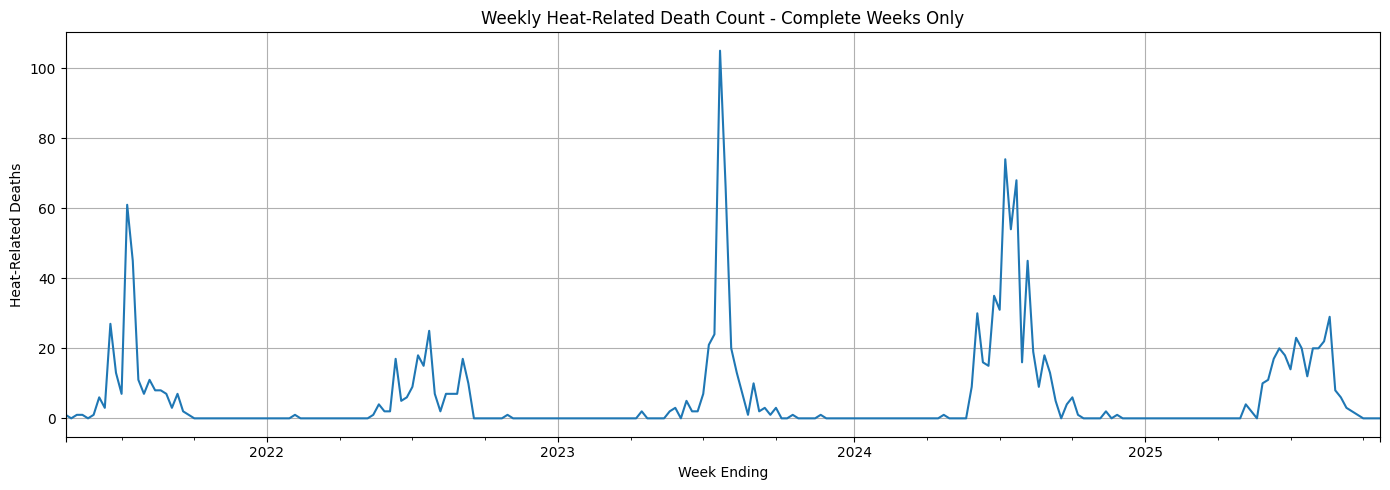

In [5]:
# Visual check of historical series
weekly_heat_ts["heat_death_count"].plot(
    figsize=(14, 5),
    title="Weekly Heat-Related Death Count - Complete Weeks Only",
    linewidth=1.5
)
plt.xlabel("Week Ending")
plt.ylabel("Heat-Related Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Optional historical weather retrieval

The uploaded heat-death files do **not** contain a complete daily weather table.

The cleanest free/open approach is to retrieve historical weather from Open-Meteo for Las Vegas. This improves the explanatory model, but the 8-week future forecast below intentionally uses a calendar + lag model because future weather values are not in the uploaded files.

Set `FETCH_WEATHER = True` when your notebook has internet access.


In [6]:
FETCH_WEATHER = True

LATITUDE = 36.1716
LONGITUDE = -115.1391
TIMEZONE = "America/Los_Angeles"

weather_daily = None

if FETCH_WEATHER:
    try:
        start_date = daily_heat_ts.index.min().strftime("%Y-%m-%d")
        end_date = daily_heat_ts.index.max().strftime("%Y-%m-%d")

        url = "https://archive-api.open-meteo.com/v1/archive"

        params = {
            "latitude": LATITUDE,
            "longitude": LONGITUDE,
            "start_date": start_date,
            "end_date": end_date,
            "daily": ",".join([
                "temperature_2m_max",
                "temperature_2m_min",
                "apparent_temperature_max",
                "apparent_temperature_min",
                "precipitation_sum",
                "rain_sum",
                "snowfall_sum",
                "wind_speed_10m_max",
                "shortwave_radiation_sum"
            ]),
            "temperature_unit": "fahrenheit",
            "wind_speed_unit": "mph",
            "precipitation_unit": "inch",
            "timezone": TIMEZONE,
        }

        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()

        weather_daily = pd.DataFrame(payload["daily"])
        weather_daily["date"] = pd.to_datetime(weather_daily["time"])
        weather_daily = weather_daily.drop(columns=["time"]).set_index("date").sort_index()

        weather_path = BASE_DIR / "las_vegas_daily_weather_open_meteo.csv"
        weather_daily.to_csv(weather_path)

        print(f"Retrieved weather from {start_date} to {end_date}")
        print(f"Saved weather data to: {weather_path}")
        display(weather_daily.head())

    except Exception as e:
        print("Weather retrieval failed. Continuing with calendar-only model features.")
        print("Error:", e)
        weather_daily = None
else:
    print("Weather retrieval skipped.")


Retrieved weather from 2021-04-19 to 2025-10-27
Saved weather data to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/las_vegas_daily_weather_open_meteo.csv


,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,shortwave_radiation_sum
date,,,,,,,,,
2021-04-19,86.1,55.7,82.5,46.8,0.0,0.0,0.0,16.2,27.84
2021-04-20,86.3,61.1,79.5,53.5,0.0,0.0,0.0,15.8,26.94
2021-04-21,79.2,65.9,69.0,54.0,0.0,0.0,0.0,26.3,26.90
2021-04-22,79.9,55.0,73.9,49.0,0.0,0.0,0.0,12.8,26.98
2021-04-23,83.8,56.7,79.7,48.6,0.0,0.0,0.0,14.3,27.77


## 4. Build weekly modeling table

For historical model validation, weather features can be included if they were successfully retrieved.

For the 8-week forecast, a separate future-ready model will use only variables we can know going forward:

- seasonal week features
- summer/heat-season flag
- lagged heat-death count
- rolling average


In [7]:
# Daily modeling table
# Restrict to dates through the last complete week so modeling is not trained on an incomplete final period.
daily_model_df = daily_heat_ts.loc[:last_complete_week_end].copy()

if weather_daily is not None:
    daily_model_df = daily_model_df.merge(
        weather_daily,
        left_index=True,
        right_index=True,
        how="left"
    )

    weather_cols = [c for c in weather_daily.columns if c in daily_model_df.columns]
    daily_model_df[weather_cols] = daily_model_df[weather_cols].ffill().bfill()

weekly_model_df = daily_model_df[["heat_death_count"]].resample("W-SUN").sum()

if weather_daily is not None:
    weather_cols = [c for c in weather_daily.columns if c in daily_model_df.columns]

    weekly_weather_mean = daily_model_df[weather_cols].resample("W-SUN").mean().add_suffix("_weekly_mean")
    weekly_weather_max = daily_model_df[[
        c for c in weather_cols
        if c.endswith("_max") or "temperature" in c or "wind_speed" in c
    ]].resample("W-SUN").max().add_suffix("_weekly_max")

    weekly_model_df = weekly_model_df.merge(
        weekly_weather_mean,
        left_index=True,
        right_index=True,
        how="left"
    ).merge(
        weekly_weather_max,
        left_index=True,
        right_index=True,
        how="left"
    )

# Feature engineering
model_df = weekly_model_df.copy()
model_df["weekofyear"] = model_df.index.isocalendar().week.astype(int)
model_df["month"] = model_df.index.month
model_df["year"] = model_df.index.year

model_df["week_sin"] = np.sin(2 * np.pi * model_df["weekofyear"] / 52.0)
model_df["week_cos"] = np.cos(2 * np.pi * model_df["weekofyear"] / 52.0)
model_df["summer_peak"] = model_df["month"].isin([6, 7, 8, 9]).astype(int)

# Lag features. Shift first to avoid leakage.
model_df["lag_1_week"] = model_df["heat_death_count"].shift(1)
model_df["rolling_4_week_avg"] = (
    model_df["heat_death_count"]
    .shift(1)
    .rolling(4, min_periods=2)
    .mean()
)

model_df = model_df.dropna().copy()

display(model_df.head())
print("Modeling rows:", len(model_df))
print("Modeling date range:", model_df.index.min().date(), "to", model_df.index.max().date())


,heat_death_count,temperature_2m_max_weekly_mean,temperature_2m_min_weekly_mean,apparent_temperature_max_weekly_mean,apparent_temperature_min_weekly_mean,precipitation_sum_weekly_mean,rain_sum_weekly_mean,snowfall_sum_weekly_mean,wind_speed_10m_max_weekly_mean,shortwave_radiation_sum_weekly_mean,temperature_2m_max_weekly_max,temperature_2m_min_weekly_max,apparent_temperature_max_weekly_max,apparent_temperature_min_weekly_max,wind_speed_10m_max_weekly_max,weekofyear,month,year,week_sin,week_cos,summer_peak,lag_1_week,rolling_4_week_avg
date,,,,,,,,,,,,,,,,,,,,,,,
2021-05-09,1,90.514286,66.071429,84.028571,58.271429,0.000000,0.000000,0.0,15.371429,29.042857,98.4,71.3,93.5,65.2,21.3,18,5,2021,0.822984,-0.568065,0,0.0,0.500000
2021-05-16,1,91.400000,68.271429,86.157143,61.171429,0.001714,0.001714,0.0,14.928571,28.734286,98.1,72.9,94.2,66.8,23.3,19,5,2021,0.748511,-0.663123,0,1.0,0.666667
2021-05-23,0,83.571429,60.342857,76.014286,52.571429,0.001143,0.001143,0.0,18.971429,29.017143,96.9,71.0,93.4,65.2,29.9,20,5,2021,0.663123,-0.748511,0,1.0,0.750000
2021-05-30,1,94.000000,68.400000,89.771429,61.585714,0.000000,0.000000,0.0,11.500000,28.005714,98.1,72.8,95.9,65.5,20.2,21,5,2021,0.568065,-0.822984,0,0.0,0.500000
2021-06-06,6,105.171429,78.642857,101.271429,72.671429,0.000000,0.000000,0.0,13.971429,29.325714,109.2,81.8,105.9,77.0,18.2,22,6,2021,0.464723,-0.885456,1,1.0,0.750000


Modeling rows: 234
Modeling date range: 2021-05-09 to 2025-10-26


## 5. Historical validation: baseline, Poisson, and Negative Binomial

This section checks whether the model can explain/predict held-out historical weekly counts.

Because heat-related deaths are count data, Poisson is the first simple model. If the data is overdispersed, Negative Binomial is usually more appropriate.


In [8]:
target = "heat_death_count"

base_features = [
    "week_sin",
    "week_cos",
    "summer_peak",
    "lag_1_week",
    "rolling_4_week_avg",
]

weather_feature_candidates = [
    "temperature_2m_max_weekly_mean",
    "apparent_temperature_max_weekly_mean",
    "temperature_2m_max_weekly_max",
    "apparent_temperature_max_weekly_max",
    "precipitation_sum_weekly_mean",
    "wind_speed_10m_max_weekly_mean",
    "shortwave_radiation_sum_weekly_mean",
]

weather_features = [c for c in weather_feature_candidates if c in model_df.columns]
features = base_features + weather_features

print("Using historical validation features:")
for f in features:
    print("-", f)

X = sm.add_constant(model_df[features], has_constant="add")
y = model_df[target]

split_index = int(len(model_df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Train period: {y_train.index.min().date()} to {y_train.index.max().date()}")
print(f"Test period:  {y_test.index.min().date()} to {y_test.index.max().date()}")
print(f"Train rows: {len(y_train)}, Test rows: {len(y_test)}")


Using historical validation features:
- week_sin
- week_cos
- summer_peak
- lag_1_week
- rolling_4_week_avg
- temperature_2m_max_weekly_mean
- apparent_temperature_max_weekly_mean
- temperature_2m_max_weekly_max
- apparent_temperature_max_weekly_max
- precipitation_sum_weekly_mean
- wind_speed_10m_max_weekly_mean
- shortwave_radiation_sum_weekly_mean
Train period: 2021-05-09 to 2024-12-01
Test period:  2024-12-08 to 2025-10-26
Train rows: 187, Test rows: 47


In [9]:
# Baseline: predict this week's heat deaths using previous week's count.
baseline_pred = X_test["lag_1_week"].clip(lower=0)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = rmse(y_test, baseline_pred)

# Poisson GLM
poisson_model = sm.GLM(y_train, X_train, family=sm.families.Poisson()).fit()
poisson_pred = poisson_model.predict(X_test).clip(lower=0)
poisson_mae = mean_absolute_error(y_test, poisson_pred)
poisson_rmse = rmse(y_test, poisson_pred)
poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid

# Negative Binomial
try:
    nb_model = sm.NegativeBinomial(y_train, X_train).fit(disp=False, maxiter=1000)
    nb_model_type = "Discrete Negative Binomial"
except Exception as e:
    print("Discrete Negative Binomial failed; falling back to GLM Negative Binomial.")
    print("Error:", e)
    nb_model = sm.GLM(y_train, X_train, family=sm.families.NegativeBinomial()).fit()
    nb_model_type = "GLM Negative Binomial"

nb_pred = nb_model.predict(X_test).clip(lower=0)
nb_mae = mean_absolute_error(y_test, nb_pred)
nb_rmse = rmse(y_test, nb_pred)

metrics = pd.DataFrame({
    "model": ["Baseline lag-1 week", "Poisson", nb_model_type],
    "MAE": [baseline_mae, poisson_mae, nb_mae],
    "RMSE": [baseline_rmse, poisson_rmse, nb_rmse],
})

display(metrics)
print("Poisson overdispersion ratio:", poisson_dispersion)

results = pd.DataFrame({
    "actual_heat_deaths": y_test,
    "baseline_lag_1_week": baseline_pred,
    "poisson_pred": poisson_pred,
    "negative_binomial_pred": nb_pred,
})

display(results.head(20))


,model,MAE,RMSE
0,Baseline lag-1 week,2.148936,4.421899
1,Poisson,1.959080,3.850278
2,Discrete Negative Binomial,1.959080,3.850278


Poisson overdispersion ratio: 7.262168017584156


,actual_heat_deaths,baseline_lag_1_week,poisson_pred,negative_binomial_pred
date,,,,
2024-12-08,0,1.0,0.008231,0.008231
2024-12-15,0,0.0,0.002256,0.002256
2024-12-22,0,0.0,0.007620,0.007620
2024-12-29,0,0.0,0.006536,0.006536
2025-01-05,0,0.0,0.004996,0.004996
2025-01-12,0,0.0,0.004018,0.004018
2025-01-19,0,0.0,0.001857,0.001857
2025-01-26,0,0.0,0.001292,0.001292
2025-02-02,0,0.0,0.005588,0.005588


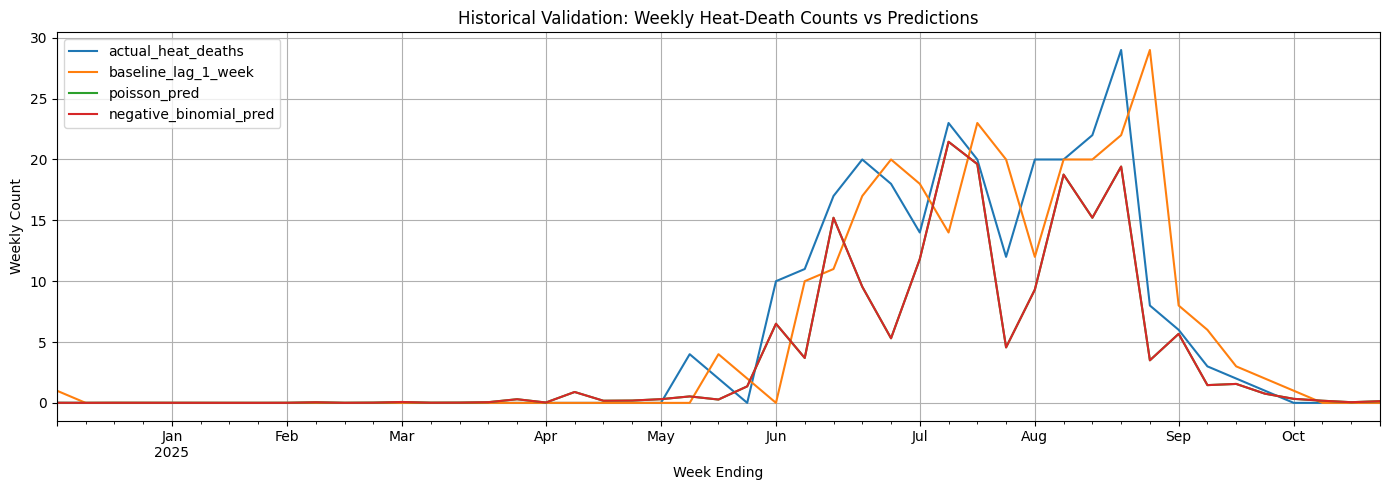

In [10]:
results.plot(
    figsize=(14, 5),
    title="Historical Validation: Weekly Heat-Death Counts vs Predictions",
    linewidth=1.5
)
plt.xlabel("Week Ending")
plt.ylabel("Weekly Count")
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Future 8-week forecast from the last complete heat-death week

This is the key forecasting section.

The forecast begins immediately after the last complete weekly bucket available in the heat-death data. This is different from simply forecasting from today's date. The reason is that the dataset itself may be several weeks or months behind.

The model used here is a future-ready Negative Binomial or Poisson model using only:

- seasonality
- summer indicator
- previous heat-death counts
- rolling average

It intentionally does not require future weather data.


In [11]:
forecast_features = [
    "week_sin",
    "week_cos",
    "summer_peak",
    "lag_1_week",
    "rolling_4_week_avg",
]

forecast_model_df = model_df.dropna(subset=forecast_features + ["heat_death_count"]).copy()

X_full_forecast = sm.add_constant(
    forecast_model_df[forecast_features],
    has_constant="add"
)
y_full_forecast = forecast_model_df["heat_death_count"]

try:
    future_model = sm.NegativeBinomial(y_full_forecast, X_full_forecast).fit(disp=False, maxiter=1000)
    future_model_name = "Negative Binomial"
except Exception as e:
    print("Negative Binomial future model failed. Falling back to Poisson.")
    print("Error:", e)
    future_model = sm.GLM(y_full_forecast, X_full_forecast, family=sm.families.Poisson()).fit()
    future_model_name = "Poisson"

print("Future forecast model used:", future_model_name)
print("Last recorded heat-death date:", last_recorded_heat_date.date())
print("Last complete heat-death week ending:", last_complete_week_end.date())
print("Forecast week endings:")
for d in forecast_week_ends:
    print("-", d.date())

# Approximate uncertainty using historical residual variation.
historical_fitted = pd.Series(
    future_model.predict(X_full_forecast).clip(0),
    index=X_full_forecast.index
)
historical_residuals = y_full_forecast - historical_fitted
residual_std = historical_residuals.std()

forecast_history = forecast_model_df["heat_death_count"].copy()
future_rows = []

for future_date in forecast_week_ends:
    weekofyear = int(future_date.isocalendar().week)
    month = int(future_date.month)

    lag_1_week = float(forecast_history.iloc[-1])
    rolling_4_week_avg = float(forecast_history.iloc[-4:].mean())

    row = pd.DataFrame([{
        "week_sin": np.sin(2 * np.pi * weekofyear / 52.0),
        "week_cos": np.cos(2 * np.pi * weekofyear / 52.0),
        "summer_peak": int(month in [6, 7, 8, 9]),
        "lag_1_week": lag_1_week,
        "rolling_4_week_avg": rolling_4_week_avg,
    }], index=[future_date])

    row_X = sm.add_constant(row, has_constant="add")
    row_X = row_X.reindex(columns=X_full_forecast.columns, fill_value=0)

    pred = float(future_model.predict(row_X).iloc[0])
    pred = max(pred, 0)

    lower_approx = max(0, pred - 1.96 * residual_std)
    upper_approx = max(0, pred + 1.96 * residual_std)

    future_rows.append({
        "week_ending": future_date,
        "predicted_heat_deaths": pred,
        "lower_approx_95": lower_approx,
        "upper_approx_95": upper_approx,
        "lag_1_week_used": lag_1_week,
        "rolling_4_week_avg_used": rolling_4_week_avg,
    })

    # Recursive forecast: predicted week becomes part of history for the next week.
    forecast_history.loc[future_date] = pred

future_forecast = pd.DataFrame(future_rows).set_index("week_ending")

forecast_output_path = BASE_DIR / "future_8_week_heat_death_forecast.csv"
future_forecast.to_csv(forecast_output_path)

display(future_forecast)
print(f"Saved forecast to: {forecast_output_path}")


Future forecast model used: Negative Binomial
Last recorded heat-death date: 2025-10-27
Last complete heat-death week ending: 2025-10-26
Forecast week endings:
- 2025-11-02
- 2025-11-09
- 2025-11-16
- 2025-11-23
- 2025-11-30
- 2025-12-07
- 2025-12-14
- 2025-12-21


,predicted_heat_deaths,lower_approx_95,upper_approx_95,lag_1_week_used,rolling_4_week_avg_used
week_ending,,,,,
2025-11-02,0.082253,0,17.006111,0.000000,0.000000
2025-11-09,0.054250,0,16.978108,0.082253,0.020563
2025-11-16,0.036499,0,16.960358,0.054250,0.034126
2025-11-23,0.025235,0,16.949093,0.036499,0.043250
2025-11-30,0.018025,0,16.941883,0.025235,0.049559
2025-12-07,0.013367,0,16.937225,0.018025,0.033502
2025-12-14,0.010335,0,16.934193,0.013367,0.023282
2025-12-21,0.008363,0,16.932221,0.010335,0.016741


Saved forecast to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/future_8_week_heat_death_forecast.csv


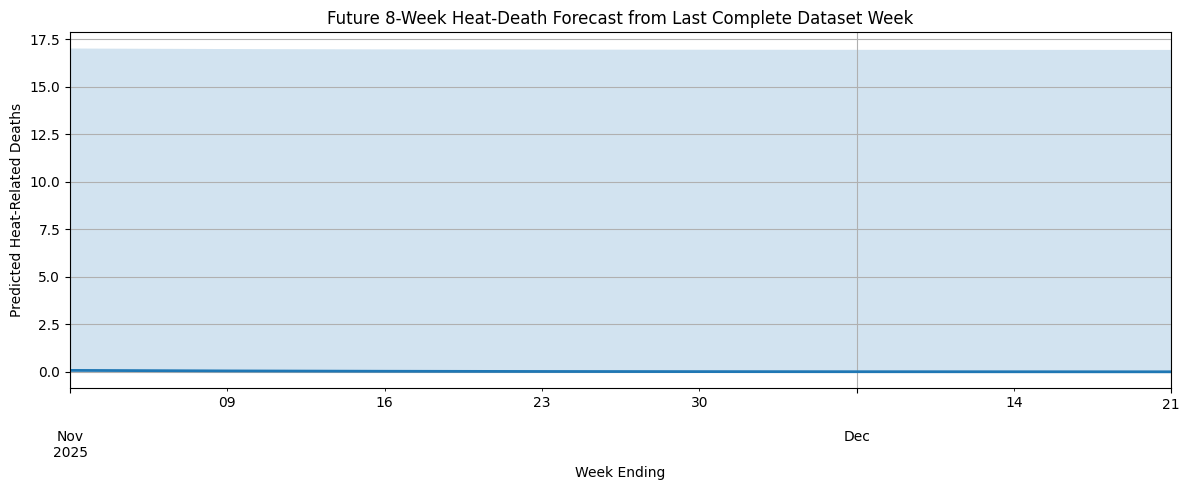

In [12]:
ax = future_forecast["predicted_heat_deaths"].plot(
    figsize=(12, 5),
    title="Future 8-Week Heat-Death Forecast from Last Complete Dataset Week",
    linewidth=2
)

ax.fill_between(
    future_forecast.index,
    future_forecast["lower_approx_95"],
    future_forecast["upper_approx_95"],
    alpha=0.2
)

plt.xlabel("Week Ending")
plt.ylabel("Predicted Heat-Related Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7. Pull public LVMPD homicide/murder data

This section retrieves public LVMPD NIBRS homicide records from the LVMPD Open Data Portal through ArcGIS REST.

The point of this section is to produce an **actual public-data comparison** for the same 8-week window as the heat-death forecast.

Again, this is not saying homicide counts validate heat-death predictions. They are different outcomes. The comparison is included because both are public-safety death-related counts over the same period.


In [13]:
LVMPD_HOMICIDE_ITEM_ID = "aced898d483c4dabaf274cb335c491c3"


def get_arcgis_item_metadata(item_id):
    """Try ArcGIS Online and the LVMPD/GISDay portal endpoint for item metadata."""
    candidate_roots = [
        "https://www.arcgis.com",
        "https://gisday23.maps.arcgis.com",
    ]

    last_error = None

    for root in candidate_roots:
        try:
            url = f"{root}/sharing/rest/content/items/{item_id}"
            response = requests.get(url, params={"f": "json"}, timeout=30)
            response.raise_for_status()
            payload = response.json()

            if payload.get("url"):
                payload["_metadata_root"] = root
                return payload

            last_error = payload

        except Exception as e:
            last_error = e

    raise RuntimeError(f"Could not retrieve ArcGIS item metadata. Last error: {last_error}")


def query_arcgis_feature_layer_geojson(service_url, layer_id=0, where="1=1", out_fields="*", batch_size=2000, max_records=50000):
    """Query a public ArcGIS FeatureServer layer into GeoJSON features."""
    layer_url = service_url.rstrip("/") + f"/{layer_id}/query"

    all_features = []
    offset = 0

    while offset < max_records:
        params = {
            "where": where,
            "outFields": out_fields,
            "returnGeometry": "true",
            "f": "geojson",
            "resultOffset": offset,
            "resultRecordCount": batch_size,
        }

        response = requests.get(layer_url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()

        if "features" not in payload:
            raise ValueError(f"Unexpected ArcGIS response: {payload}")

        features = payload["features"]
        if not features:
            break

        all_features.extend(features)

        if len(features) < batch_size:
            break

        offset += batch_size

    return all_features


def arcgis_features_to_dataframe(features):
    rows = []

    for feature in features:
        props = feature.get("properties") or {}
        geom = feature.get("geometry") or {}
        coords = geom.get("coordinates")

        row = props.copy()

        if coords and len(coords) >= 2:
            row["lon"] = coords[0]
            row["lat"] = coords[1]
        else:
            row["lon"] = np.nan
            row["lat"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def convert_possible_arcgis_date(series):
    """Convert possible ArcGIS date field to pandas datetime."""
    s = series.copy()

    # Numeric ArcGIS dates are usually milliseconds since epoch.
    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()

        if non_null.empty:
            return pd.to_datetime(s, errors="coerce")

        median_value = non_null.median()

        if median_value > 10**11:
            return pd.to_datetime(s, unit="ms", errors="coerce")
        elif median_value > 10**8:
            return pd.to_datetime(s, unit="s", errors="coerce")

    return pd.to_datetime(s, errors="coerce")


def infer_best_date_column(df):
    """Infer the most useful date column from public LVMPD fields."""
    preferred_keywords = [
        "report", "reported", "occur", "occurred", "incident", "date", "datetime", "time"
    ]

    candidates = []

    for col in df.columns:
        col_lower = str(col).lower()
        if any(k in col_lower for k in preferred_keywords):
            converted = convert_possible_arcgis_date(df[col])
            valid_count = converted.notna().sum()

            if valid_count > 0:
                candidates.append({
                    "column": col,
                    "valid_count": valid_count,
                    "min_date": converted.min(),
                    "max_date": converted.max(),
                })

    if not candidates:
        raise ValueError("Could not infer a date column in the LVMPD homicide dataset.")

    candidate_df = pd.DataFrame(candidates).sort_values(
        by=["valid_count", "max_date"],
        ascending=[False, False]
    )

    display(candidate_df)

    # Prefer a reported/occurred field if present; otherwise use the strongest candidate.
    for keyword in ["reported", "report", "occurred", "occur", "incident"]:
        matching = candidate_df[candidate_df["column"].str.lower().str.contains(keyword, na=False)]
        if not matching.empty:
            return matching.iloc[0]["column"]

    return candidate_df.iloc[0]["column"]


try:
    item_meta = get_arcgis_item_metadata(LVMPD_HOMICIDE_ITEM_ID)
    service_url = item_meta.get("url")

    print("LVMPD item title:", item_meta.get("title"))
    print("LVMPD service URL:", service_url)

    homicide_features = query_arcgis_feature_layer_geojson(service_url)
    homicide_df = arcgis_features_to_dataframe(homicide_features)

    if homicide_df.empty:
        raise ValueError("LVMPD homicide query returned no records.")

    best_date_col = infer_best_date_column(homicide_df)
    homicide_df["homicide_date"] = convert_possible_arcgis_date(homicide_df[best_date_col]).dt.tz_localize(None)
    homicide_df = homicide_df.dropna(subset=["homicide_date"]).copy()

    print("Selected homicide date column:", best_date_col)
    print("LVMPD homicide records loaded:", len(homicide_df))
    print("LVMPD homicide date range:", homicide_df["homicide_date"].min().date(), "to", homicide_df["homicide_date"].max().date())
    print("Columns:")
    print(homicide_df.columns.tolist())

    display(homicide_df.head())

except Exception as e:
    print("Could not retrieve LVMPD homicide data.")
    print("Error:", e)
    homicide_df = pd.DataFrame()


LVMPD item title: LVMPD Reported NIBRS Homicide
LVMPD service URL: https://services.arcgis.com/jjSk6t82vIntwDbs/arcgis/rest/services/LVMPD_Reported_NIBRS_Homicides/FeatureServer


,column,valid_count,min_date,max_date
0,ReportedOn,140,2025-01-03 01:21:46.000000000,2026-04-28 10:04:00.000000000
1,DateDif,140,1970-01-01 00:00:00.000000012,1970-01-01 00:00:00.000000492


Selected homicide date column: ReportedOn
LVMPD homicide records loaded: 140
LVMPD homicide date range: 2025-01-03 to 2026-04-28
Columns:
['OBJECTID', 'Event_Number', 'ReportedOn', 'Location', 'CSZ', 'Area_Command', 'Beat', 'OffenseGroup', 'CrimeAgainst', 'OffenseCategory', 'Offense', 'NIBRSOffenseCode', 'ViolentCrime', 'ShootingVictims', 'ShootingVictimCount', 'Weapons', 'Longitude', 'Latitude', 'DateDif', 'LocationType', 'lon', 'lat', 'homicide_date']


,OBJECTID,Event_Number,ReportedOn,Location,CSZ,Area_Command,Beat,OffenseGroup,CrimeAgainst,OffenseCategory,Offense,NIBRSOffenseCode,ViolentCrime,ShootingVictims,ShootingVictimCount,Weapons,Longitude,Latitude,DateDif,LocationType,lon,lat,homicide_date
0,682,LLV250100006826,1735867306000,STOCKER ST & W OWENS AVE,NORTH LAS VEGAS,DTAC,B1,A,Person,HOMICIDE OFFENSES,Murder and Nonnegligent Manslaughter,09A,TRUE,Y,1,Firearm (Type Not Stated),-115.140497,36.188388,492,Air/Bus/Train Terminal,-115.140497,36.188388,2025-01-03 01:21:46.000
1,1155,LLV250100011167,1735951500000,4700 SACKS DR,LAS VEGAS,SEAC,J4,A,Person,HOMICIDE OFFENSES,Murder and Nonnegligent Manslaughter,09A,TRUE,Y,1,Firearm (Type Not Stated),-115.060037,36.103036,491,Highway/Road/Alley,-115.060037,36.103036,2025-01-04 00:45:00.000
2,2016,LLV250100020990,1736193451377,3700 FAMIGLIA DR,LAS VEGAS,EAC,O5,A,Person,HOMICIDE OFFENSES,Murder and Nonnegligent Manslaughter,09A,TRUE,N,0,Drugs/Narcotics/Sleeping Pills,-115.189787,35.985708,488,Residence/Home,-115.189787,35.985708,2025-01-06 19:57:31.377
3,3208,LLV250100033845,1736498340000,4800 E TROPICANA AVE,LAS VEGAS,SEAC,H3,A,Person,HOMICIDE OFFENSES,Justifiable Homicide,09C,FALSE,Y,1,Firearm (Type Not Stated),-115.068972,36.099957,485,Residence/Home,-115.068972,36.099957,2025-01-10 08:39:00.000
4,3522,LLV250100037211,1736578200000,1400 BRACKEN AVE,LAS VEGAS,DTAC,C4,A,Person,HOMICIDE OFFENSES,Justifiable Homicide,09C,FALSE,N,0,"Knife/Cutting Instrument (Icepick, Ax, Etc.)",-115.134356,36.153057,484,Residence/Home,-115.134356,36.153057,2025-01-11 06:50:00.000


## 8. Compare 8-week heat-death forecast to actual LVMPD homicide counts

This comparison uses the exact same weekly buckets as the heat-death forecast.

Interpretation:

- `predicted_heat_deaths` = model forecast from the coroner heat-death dataset
- `actual_lvmpd_homicides` = public LVMPD homicide records that occurred/reported in that same week

These are different outcomes, so this is a contextual comparison graph rather than a forecast accuracy graph.


In [14]:
comparison_df = future_forecast.copy()
comparison_df["actual_lvmpd_homicides"] = 0

if not homicide_df.empty:
    homicide_window = homicide_df[
        (homicide_df["homicide_date"] >= forecast_window_start) &
        (homicide_df["homicide_date"] <= forecast_window_end)
    ].copy()

    if not homicide_window.empty:
        homicide_weekly = (
            homicide_window
            .set_index("homicide_date")
            .sort_index()
            .resample("W-SUN")
            .size()
            .rename("actual_lvmpd_homicides")
        )

        comparison_df["actual_lvmpd_homicides"] = (
            homicide_weekly
            .reindex(comparison_df.index, fill_value=0)
            .astype(int)
        )

    print("Forecast comparison window:")
    print(f"Start: {forecast_window_start.date()}")
    print(f"End:   {forecast_window_end.date()}")
    print("LVMPD homicide records inside window:", len(homicide_window))

else:
    homicide_window = pd.DataFrame()
    print("LVMPD homicide data unavailable, so comparison graph will only show heat-death forecast.")

comparison_output_path = BASE_DIR / "heat_forecast_vs_lvmpd_homicides_comparison.csv"
comparison_df.to_csv(comparison_output_path)

display(comparison_df)
print(f"Saved comparison table to: {comparison_output_path}")


Forecast comparison window:
Start: 2025-10-27
End:   2025-12-21
LVMPD homicide records inside window: 14


,predicted_heat_deaths,lower_approx_95,upper_approx_95,lag_1_week_used,rolling_4_week_avg_used,actual_lvmpd_homicides
week_ending,,,,,,
2025-11-02,0.082253,0,17.006111,0.000000,0.000000,1
2025-11-09,0.054250,0,16.978108,0.082253,0.020563,3
2025-11-16,0.036499,0,16.960358,0.054250,0.034126,2
2025-11-23,0.025235,0,16.949093,0.036499,0.043250,0
2025-11-30,0.018025,0,16.941883,0.025235,0.049559,1
2025-12-07,0.013367,0,16.937225,0.018025,0.033502,4
2025-12-14,0.010335,0,16.934193,0.013367,0.023282,1
2025-12-21,0.008363,0,16.932221,0.010335,0.016741,2


Saved comparison table to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/heat_forecast_vs_lvmpd_homicides_comparison.csv


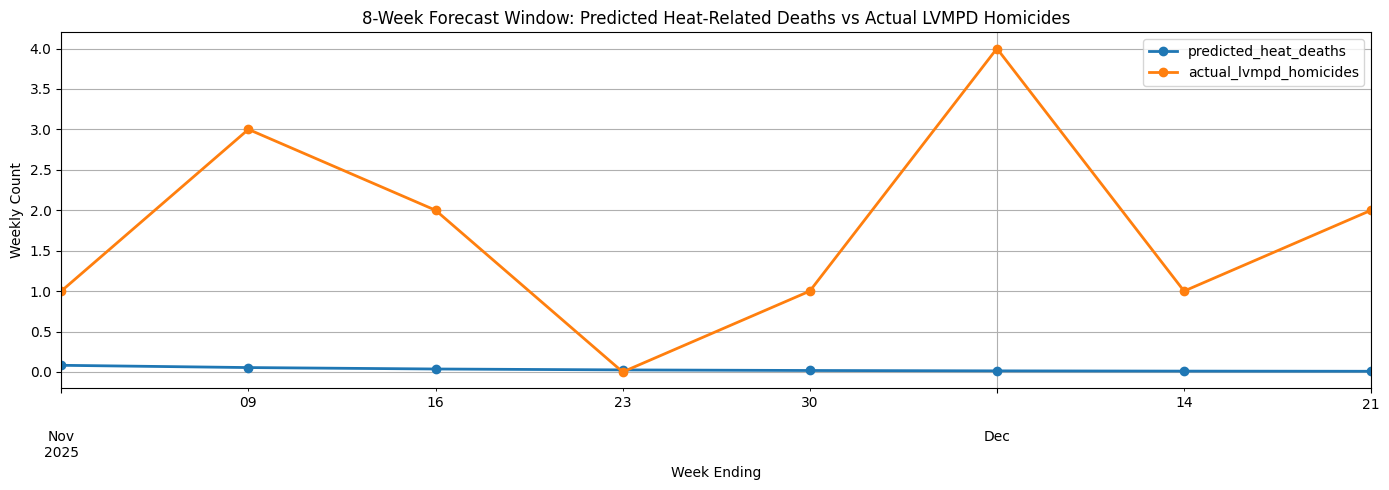

In [15]:
ax = comparison_df[["predicted_heat_deaths", "actual_lvmpd_homicides"]].plot(
    figsize=(14, 5),
    title="8-Week Forecast Window: Predicted Heat-Related Deaths vs Actual LVMPD Homicides",
    marker="o",
    linewidth=2
)

plt.xlabel("Week Ending")
plt.ylabel("Weekly Count")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Google-style interactive map with overlaid heat-death and homicide data

This map is closer to the intended output:

- It uses a street-map base layer similar to Google Maps.
- It overlays a heat-death density layer using ZIP-code centroids.
- It overlays LVMPD public homicide points.
- It highlights homicide points that fall inside the same 8-week forecast window.

Why ZIP centroids for heat deaths?

The heat-death files contain case-level details and sometimes exact or partial locations. To keep the map safer and avoid exposing sensitive case-level locations, this notebook maps heat deaths by ZIP centroid instead of exact address.


In [16]:
# Install folium if needed.
try:
    import folium
    from folium.plugins import HeatMap, MarkerCluster, Fullscreen, MeasureControl
    from IPython.display import IFrame, display as ipy_display
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium"])
    import folium
    from folium.plugins import HeatMap, MarkerCluster, Fullscreen, MeasureControl
    from IPython.display import IFrame, display as ipy_display

LAS_VEGAS_CENTER = [36.1716, -115.1391]


def clean_zip(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    # Handles values like 89102.0 or text containing 89102.
    match = re.search(r"(89\d{3})", text)
    if match:
        return match.group(1)

    # Float-looking ZIPs
    try:
        as_int = int(float(text))
        as_str = str(as_int)
        if re.match(r"^89\d{3}$", as_str):
            return as_str
    except Exception:
        pass

    return np.nan


zip_cols = [
    "Incident Location Zip Code",
    "Death Location Zip Code",
]

available_zip_cols = [col for col in zip_cols if col in heat_df.columns]

heat_geo_df = heat_df.copy()
heat_geo_df["zip_code"] = np.nan

for col in available_zip_cols:
    heat_geo_df["zip_code"] = heat_geo_df["zip_code"].fillna(
        heat_geo_df[col].apply(clean_zip)
    )

heat_zip_counts = (
    heat_geo_df
    .dropna(subset=["zip_code"])
    .groupby("zip_code")
    .agg(
        heat_death_count=("Case #", "nunique"),
        first_death_date=("date", "min"),
        last_death_date=("date", "max")
    )
    .reset_index()
    .sort_values("heat_death_count", ascending=False)
)

print("Heat-death ZIP groups available for mapping:", len(heat_zip_counts))
display(heat_zip_counts.head(20))


Heat-death ZIP groups available for mapping: 69


,zip_code,heat_death_count,first_death_date,last_death_date
23,89101,112,2021-06-20,2024-09-13
26,89104,84,2021-06-06,2024-10-05
11,89030,83,2021-05-27,2024-09-30
27,89106,62,2021-06-17,2024-10-06
24,89102,60,2021-05-06,2024-11-15
39,89121,59,2021-06-09,2024-09-02
37,89119,45,2021-04-19,2024-08-10
61,89169,43,2021-06-07,2024-09-28
33,89115,37,2021-06-06,2024-09-05
40,89122,30,2021-07-07,2024-09-07


In [17]:
# Geocode ZIP-code centroids using Nominatim with caching.
# This keeps requests low because we only geocode unique ZIPs, not individual records.

geocode_cache_path = BASE_DIR / "heat_zip_geocode_cache.csv"

if geocode_cache_path.exists():
    geocode_cache = pd.read_csv(geocode_cache_path, dtype={"zip_code": str})
else:
    geocode_cache = pd.DataFrame(columns=["zip_code", "lat", "lon", "display_name"])


def geocode_zip_nominatim(zip_code):
    existing = geocode_cache[geocode_cache["zip_code"].astype(str) == str(zip_code)]

    if not existing.empty:
        row = existing.iloc[0]
        return float(row["lat"]), float(row["lon"]), row.get("display_name", "")

    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "postalcode": str(zip_code),
        "country": "United States",
        "state": "Nevada",
        "format": "json",
        "limit": 1,
    }

    headers = {
        "User-Agent": "heat-death-lvmpd-map-notebook/2.0"
    }

    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()
    data = response.json()

    # Respect public Nominatim usage: max 1 request/sec.
    time.sleep(1.1)

    if not data:
        return np.nan, np.nan, ""

    result = data[0]
    return float(result["lat"]), float(result["lon"]), result.get("display_name", "")


if not heat_zip_counts.empty:
    geocoded_rows = []

    for _, row in heat_zip_counts.iterrows():
        zip_code = str(row["zip_code"])

        try:
            lat, lon, display_name = geocode_zip_nominatim(zip_code)
            geocoded_rows.append({
                "zip_code": zip_code,
                "lat": lat,
                "lon": lon,
                "display_name": display_name,
            })
        except Exception as e:
            print(f"Could not geocode ZIP {zip_code}: {e}")

    new_geocode_cache = pd.DataFrame(geocoded_rows)

    if not new_geocode_cache.empty:
        geocode_cache = (
            pd.concat([geocode_cache, new_geocode_cache], ignore_index=True)
            .drop_duplicates(subset=["zip_code"], keep="last")
        )
        geocode_cache.to_csv(geocode_cache_path, index=False)

    heat_zip_map_df = heat_zip_counts.merge(
        geocode_cache,
        on="zip_code",
        how="left"
    ).dropna(subset=["lat", "lon"])

else:
    heat_zip_map_df = pd.DataFrame()

print("Mapped heat-death ZIP groups:", len(heat_zip_map_df))
display(heat_zip_map_df.head(20))


Mapped heat-death ZIP groups: 0


,zip_code,heat_death_count,first_death_date,last_death_date,lat,lon,display_name


In [18]:
# Create the Google-style interactive map.
# Note: true Google Maps tiles require a Google API key and terms compliance.
# This notebook uses free/open tiles that give a similar street-map experience.

m = folium.Map(
    location=LAS_VEGAS_CENTER,
    zoom_start=10,
    tiles=None,
    control_scale=True
)

# Google-like base layers
folium.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap",
    control=True
).add_to(m)

folium.TileLayer(
    tiles="CartoDB positron",
    name="Light street map",
    control=True
).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri — Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China, TomTom",
    name="Esri World Street Map",
    control=True,
    overlay=False,
).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
    name="Satellite imagery",
    control=True,
    overlay=False,
).add_to(m)

# Heat-death ZIP density layer
if not heat_zip_map_df.empty:
    heat_points = heat_zip_map_df[["lat", "lon", "heat_death_count"]].values.tolist()

    HeatMap(
        heat_points,
        name="Heat-related death density by ZIP",
        radius=34,
        blur=22,
        max_zoom=13,
    ).add_to(m)

    heat_zip_layer = folium.FeatureGroup(name="Heat-death ZIP summaries", show=True)

    for _, row in heat_zip_map_df.iterrows():
        popup = (
            f"<b>Heat-related deaths by ZIP</b><br>"
            f"ZIP: {row['zip_code']}<br>"
            f"Heat-related deaths: {int(row['heat_death_count'])}<br>"
            f"First date: {pd.to_datetime(row['first_death_date']).date()}<br>"
            f"Last date: {pd.to_datetime(row['last_death_date']).date()}"
        )

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=max(5, min(22, row["heat_death_count"] / 5)),
            color="red",
            fill=True,
            fill_color="red",
            fill_opacity=0.35,
            popup=folium.Popup(popup, max_width=320),
            tooltip=f"ZIP {row['zip_code']}: {int(row['heat_death_count'])} heat deaths",
        ).add_to(heat_zip_layer)

    heat_zip_layer.add_to(m)

else:
    print("No heat-death ZIP data was available for the heatmap.")

# LVMPD homicide layers
if not homicide_df.empty:
    homicide_points_df = homicide_df.dropna(subset=["lat", "lon", "homicide_date"]).copy()

    all_homicide_layer = MarkerCluster(name="All LVMPD homicide points").add_to(m)

    forecast_homicide_layer = folium.FeatureGroup(
        name="LVMPD homicides inside 8-week forecast window",
        show=True
    )

    # Try useful popup fields without exposing too much detail.
    possible_popup_fields = [
        "Offense",
        "Offense Category",
        "NIBRSOffenseCode",
        "Area Command",
        "Beat",
        "Location",
        "Address",
        "Event Number",
    ]
    popup_fields = [c for c in possible_popup_fields if c in homicide_points_df.columns]

    for _, row in homicide_points_df.iterrows():
        date_value = pd.to_datetime(row["homicide_date"]).date()
        inside_window = forecast_window_start <= row["homicide_date"] <= forecast_window_end

        popup_lines = [
            "<b>LVMPD public homicide record</b>",
            f"Date: {date_value}",
        ]

        for field in popup_fields[:5]:
            value = row.get(field)
            if pd.notna(value):
                popup_lines.append(f"{field}: {value}")

        popup = "<br>".join(popup_lines)

        if inside_window:
            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=7,
                color="blue",
                fill=True,
                fill_color="blue",
                fill_opacity=0.85,
                popup=folium.Popup(popup, max_width=350),
                tooltip=f"Forecast-window homicide: {date_value}",
            ).add_to(forecast_homicide_layer)
        else:
            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=4,
                color="black",
                fill=True,
                fill_color="black",
                fill_opacity=0.65,
                popup=folium.Popup(popup, max_width=350),
                tooltip=f"LVMPD homicide: {date_value}",
            ).add_to(all_homicide_layer)

    forecast_homicide_layer.add_to(m)
else:
    print("No LVMPD homicide points available for overlay.")

# Add helpers
Fullscreen(position="topleft").add_to(m)
MeasureControl(position="topleft").add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

map_output_path = BASE_DIR / "google_style_heat_deaths_lvmpd_homicide_overlay.html"
m.save(map_output_path)

print(f"Saved interactive map to: {map_output_path}")

# Display inside notebook
m


No heat-death ZIP data was available for the heatmap.
Saved interactive map to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/google_style_heat_deaths_lvmpd_homicide_overlay.html


## 10. Optional: embed saved map as an iframe

If the map does not display directly in your environment, run this cell to embed the saved HTML map.


In [19]:
from IPython.display import IFrame
IFrame(src=str(map_output_path), width="100%", height=720)


## 11. Coefficient interpretation

For count models, exponentiated coefficients are incidence rate ratios, often abbreviated as IRR.

- IRR greater than 1 means the feature is associated with a higher expected count.
- IRR less than 1 means the feature is associated with a lower expected count.

Interpret the model cautiously because this is an explanatory model based on limited public/coroner data.


In [20]:
def coefficient_table(model, model_name):
    params = model.params
    conf = model.conf_int()

    out = pd.DataFrame({
        "coefficient": params,
        "IRR": np.exp(params),
        "CI_lower_IRR": np.exp(conf[0]),
        "CI_upper_IRR": np.exp(conf[1]),
    })

    out["model"] = model_name
    return out

poisson_coef = coefficient_table(poisson_model, "Poisson")
nb_coef = coefficient_table(nb_model, "Negative Binomial")
future_coef = coefficient_table(future_model, f"Future Forecast Model - {future_model_name}")

display(poisson_coef)
display(nb_coef)
display(future_coef)


,coefficient,IRR,CI_lower_IRR,CI_upper_IRR,model
const,-15.580045,1.712665e-07,1.871583e-08,0.000002,Poisson
week_sin,0.397696,1.488391e+00,1.011757e+00,2.189566,Poisson
week_cos,-0.152979,8.581478e-01,3.762512e-01,1.957250,Poisson
summer_peak,0.274812,1.316283e+00,8.027180e-01,2.158417,Poisson
lag_1_week,0.003519,1.003525e+00,1.000233e+00,1.006828,Poisson
rolling_4_week_avg,0.011664,1.011733e+00,1.005989e+00,1.017510,Poisson
temperature_2m_max_weekly_mean,0.126171,1.134476e+00,1.069800e+00,1.203063,Poisson
apparent_temperature_max_weekly_mean,-0.004152,9.958570e-01,9.452242e-01,1.049202,Poisson
temperature_2m_max_weekly_max,0.012769,1.012851e+00,9.711764e-01,1.056314,Poisson
apparent_temperature_max_weekly_max,0.044821,1.045841e+00,1.004633e+00,1.088740,Poisson


,coefficient,IRR,CI_lower_IRR,CI_upper_IRR,model
const,-15.580045,1.712665e-07,NaN,NaN,Negative Binomial
week_sin,0.397696,1.488391e+00,NaN,NaN,Negative Binomial
week_cos,-0.152979,8.581478e-01,NaN,NaN,Negative Binomial
summer_peak,0.274812,1.316283e+00,NaN,NaN,Negative Binomial
lag_1_week,0.003519,1.003525e+00,NaN,NaN,Negative Binomial
rolling_4_week_avg,0.011664,1.011733e+00,NaN,NaN,Negative Binomial
temperature_2m_max_weekly_mean,0.126171,1.134476e+00,NaN,NaN,Negative Binomial
apparent_temperature_max_weekly_mean,-0.004152,9.958570e-01,NaN,NaN,Negative Binomial
temperature_2m_max_weekly_max,0.012769,1.012851e+00,NaN,NaN,Negative Binomial
apparent_temperature_max_weekly_max,0.044821,1.045841e+00,NaN,NaN,Negative Binomial


,coefficient,IRR,CI_lower_IRR,CI_upper_IRR,model
const,-1.452086e+00,0.234081,0.166472,0.329148,Future Forecast Model - Negative Binomial
week_sin,-1.141622e+00,0.319301,0.245146,0.415886,Future Forecast Model - Negative Binomial
week_cos,-3.495032e+00,0.030348,0.019166,0.048054,Future Forecast Model - Negative Binomial
summer_peak,7.819934e-01,2.185825,1.420097,3.364441,Future Forecast Model - Negative Binomial
lag_1_week,1.305264e-02,1.013138,1.010234,1.016051,Future Forecast Model - Negative Binomial
rolling_4_week_avg,-1.468174e-03,0.998533,0.993091,1.004005,Future Forecast Model - Negative Binomial
alpha,3.604242e-10,1.000000,1.000000,1.000000,Future Forecast Model - Negative Binomial


## Final notes

This notebook now focuses on what the available data can honestly support:

1. **Heat-death forecasting** from the coroner/heat files.
2. **Public homicide comparison** from LVMPD open data for the same 8-week window.
3. **Interactive map overlay** using a Google-style basemap, heat-death ZIP density, and homicide point data.

Key limitation:

The LVMPD homicide count is not the actual outcome for heat deaths. It is a separate public dataset used for time-window and spatial comparison. To validate heat-death forecasts, you would need newer coroner/heat-death records after the dataset cutoff.
